# Lab 04: Feature Extraction - Histogram-Based Methods

Every method below turns an image into a **feature vector** (a short list of numbers). Each section follows the same pattern:
**idea -> step-by-step on the image -> final feature vector**, so you can see what each step actually produces.

| # | Method | Vector length | Scope |
|---|---|---|---|
| 1 | HOG | long (depends on image size) | per cell, then joined |
| 2 | LBP | 10 | whole image |
| 3 | Color histogram | bins (here 8x8x8 = 512) | whole image |
| 4 | HED (edge directions) | 8 | whole image |
| 5 | HIG (intensity gradients) | 9 | whole image |
| 6 | Texture energy and contrast | 2 x 256 | whole image |

Filtering, convolution and edge detection (manual sections 4-5) are intentionally not included here.

color shape: (350, 233, 3) | gray shape: (350, 233) | dtype: uint8


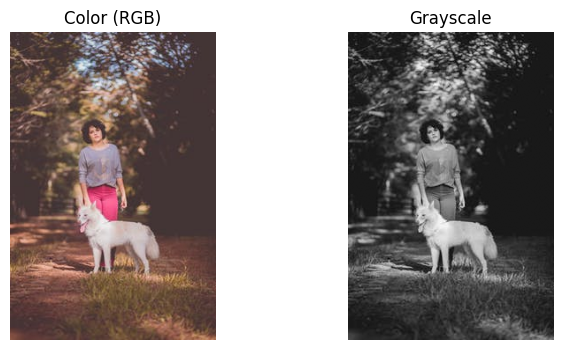

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
from skimage import exposure

IMAGE_PATH = 'Data/image.jpg'

bgr  = cv2.imread(IMAGE_PATH)                       # color image, OpenCV order = BGR
assert bgr is not None, f'Could not load {IMAGE_PATH}'
rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)         # for matplotlib
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)        # most methods need grayscale

print('color shape:', bgr.shape, '| gray shape:', gray.shape, '| dtype:', gray.dtype)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(rgb);                     ax[0].set_title('Color (RGB)');  ax[0].axis('off')
ax[1].imshow(gray, cmap='gray');       ax[1].set_title('Grayscale');    ax[1].axis('off')
plt.show()

## 1. HOG: Histogram of Oriented Gradients

**Idea:** shape is described by edge directions. Split the image into small cells, build a histogram of gradient directions in each cell,
normalize groups of cells (blocks) for lighting robustness, and join everything into one vector.

**Steps:** grayscale -> Sobel gradients (magnitude + angle) -> 8x8 cells -> orientation histogram per cell -> 2x2 block normalization -> concatenate.

**Step 1-2: gradients.** Magnitude says how strong the edge is, angle says which way it points.

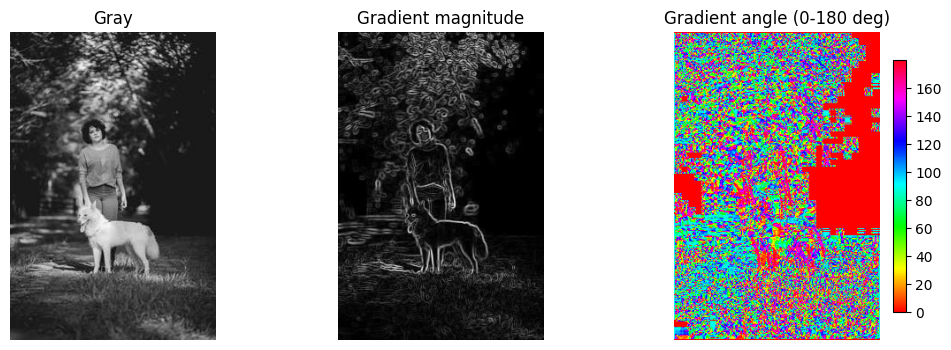

In [2]:
dx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
dy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(dx**2 + dy**2)
angle = np.degrees(np.arctan2(dy, dx)) % 180        # unsigned angle 0..180, as HOG uses

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gray, cmap='gray');          ax[0].set_title('Gray')
ax[1].imshow(magnitude, cmap='gray');     ax[1].set_title('Gradient magnitude')
im = ax[2].imshow(angle, cmap='hsv');     ax[2].set_title('Gradient angle (0-180 deg)')
plt.colorbar(im, ax=ax[2], fraction=0.046)
for a in ax: a.axis('off')
plt.show()

**Step 3-4: one cell's histogram.** Take a single 8x8 cell and let each pixel vote for its angle bin, weighted by its magnitude (9 bins of 20 degrees).

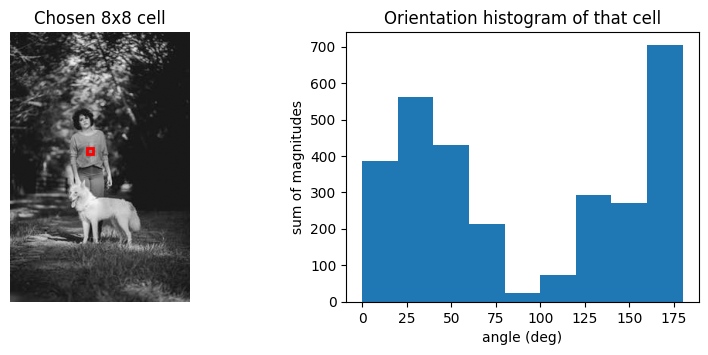

cell histogram (9 values): [385.5 563.2 430.9 213.   24.   73.8 291.8 271.3 704.5]


In [3]:
r, c = 150, 100                                     # top-left corner of the chosen cell
cell_mag = magnitude[r:r+8, c:c+8]
cell_ang = angle[r:r+8, c:c+8]
cell_hist, edges = np.histogram(cell_ang, bins=9, range=(0, 180), weights=cell_mag)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].imshow(gray, cmap='gray')
ax[0].add_patch(plt.Rectangle((c-0.5, r-0.5), 8, 8, fill=False, edgecolor='red', linewidth=2))
ax[0].set_title('Chosen 8x8 cell'); ax[0].axis('off')
ax[1].bar(edges[:-1], cell_hist, width=20, align='edge')
ax[1].set_title('Orientation histogram of that cell'); ax[1].set_xlabel('angle (deg)'); ax[1].set_ylabel('sum of magnitudes')
plt.show()
print('cell histogram (9 values):', np.round(cell_hist, 1))

**Step 5-6: full HOG.** `skimage.hog` does all cells and block normalization at once and returns the final vector plus a picture.

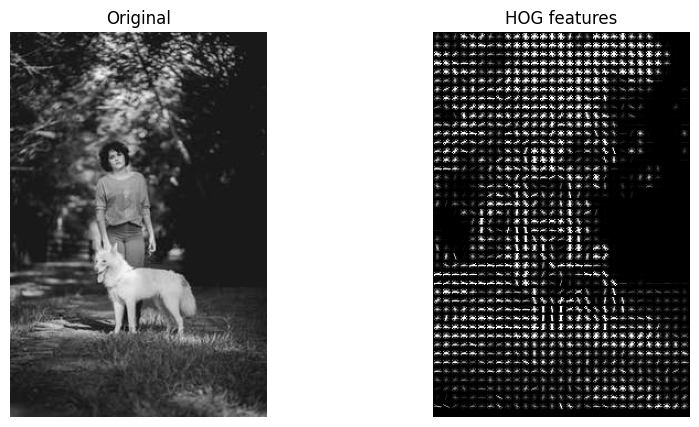

cells: 43 x 29 | blocks: 1176 | values per block: 2*2*9 = 36
feature vector length: 42336 (= blocks x 36 = 42336 )
first 10 values: [0.241 0.052 0.003 0.105 0.168 0.086 0.106 0.044 0.117 0.122]


In [4]:
features, hog_image = hog(gray, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gray, cmap='gray');                 ax[0].set_title('Original');     ax[0].axis('off')
ax[1].imshow(hog_image_rescaled, cmap='gray');   ax[1].set_title('HOG features'); ax[1].axis('off')
plt.show()

cells_y, cells_x = gray.shape[0] // 8, gray.shape[1] // 8
blocks = (cells_y - 1) * (cells_x - 1)
print('cells:', cells_y, 'x', cells_x, '| blocks:', blocks, '| values per block: 2*2*9 = 36')
print('feature vector length:', features.shape[0], '(= blocks x 36 =', blocks * 36, ')')
print('first 10 values:', np.round(features[:10], 3))

**Takeaway:** the vector is long because it keeps *where* each edge direction occurs. Resize images to one size first or vectors will not match.

## 2. LBP: Local Binary Pattern

**Idea:** describe texture by comparing each pixel with its neighbors. Neighbor >= center gives 1, otherwise 0. The 8 bits form a number; the histogram of those numbers over the image is the texture signature.

**Steps:** grayscale -> neighborhood (radius 1, 8 points) -> compare to center -> bits form a code -> histogram of codes.

**Step 1: the logic on one pixel**, done by hand.

In [5]:
r, c = 80, 80                                       # a pixel on a brightness edge, so the pattern is interesting
patch = gray[r-1:r+2, c-1:c+2].astype(int)
center = int(patch[1, 1])
clockwise = [int(v) for v in (patch[0,0], patch[0,1], patch[0,2], patch[1,2], patch[2,2], patch[2,1], patch[2,0], patch[1,0])]
bits = [1 if n >= center else 0 for n in clockwise]
code_value = sum(b << (7 - i) for i, b in enumerate(bits))

print('3x3 patch:\n', patch)
print('center =', center)
print('neighbors clockwise from top-left:', clockwise)
print('bits (neighbor >= center):', bits, '->', ''.join(map(str, bits)), '=', code_value)

3x3 patch:
 [[130 133 119]
 [109 107  99]
 [ 85  94  93]]
center = 107
neighbors clockwise from top-left: [130, 133, 119, 99, 93, 94, 85, 109]
bits (neighbor >= center): [1, 1, 1, 0, 0, 0, 0, 1] -> 11100001 = 225


**Step 2-3: LBP for every pixel.** `uniform` keeps only patterns with at most 2 bit changes, so every pixel gets a code 0..9 (10 possible values for 8 points).

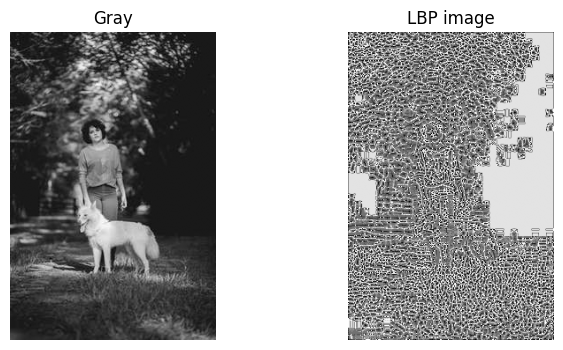

unique LBP codes in image: [0 1 2 3 4 5 6 7 8 9]


In [6]:
radius = 1
n_points = 8 * radius
lbp_image = local_binary_pattern(gray, n_points, radius, method='uniform')

plt.figure(figsize=(8, 4))
plt.subplot(121); plt.imshow(gray, cmap='gray');      plt.title('Gray');      plt.axis('off')
plt.subplot(122); plt.imshow(lbp_image, cmap='gray'); plt.title('LBP image'); plt.axis('off')
plt.show()
print('unique LBP codes in image:', np.unique(lbp_image).astype(int))

**Step 4-5: histogram = feature vector.** Normalize so images of different sizes are comparable.

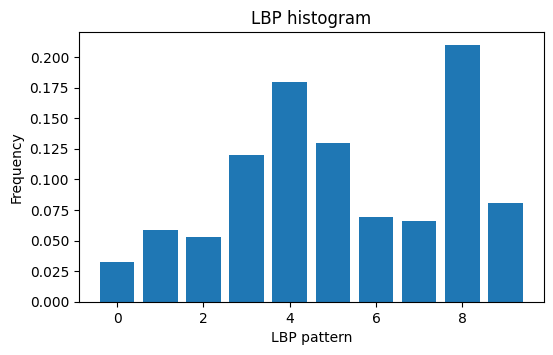

LBP feature vector (10 values): [0.032 0.059 0.053 0.12  0.18  0.13  0.069 0.066 0.21  0.081] | sum = 1.0


In [7]:
hist, _ = np.histogram(lbp_image.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
hist = hist.astype('float')
hist /= (hist.sum() + 1e-6)

plt.figure(figsize=(6, 3.5))
plt.bar(range(0, n_points + 2), hist)
plt.title('LBP histogram'); plt.xlabel('LBP pattern'); plt.ylabel('Frequency')
plt.show()
lbp_vector = hist
print('LBP feature vector (10 values):', np.round(lbp_vector, 3), '| sum =', round(lbp_vector.sum(), 3))

**Takeaway:** only 10 numbers describe the texture. Two images with similar textures will have similar bars.

## 3. Histogram of Color

**Idea:** count how many pixels fall in each color range. It captures the overall color makeup and ignores where colors are.

**Steps:** choose a color space (RGB or HSV) -> divide each channel into bins -> count pixels per bin.

**Per-channel view (RGB).** One 256-bin histogram per channel.

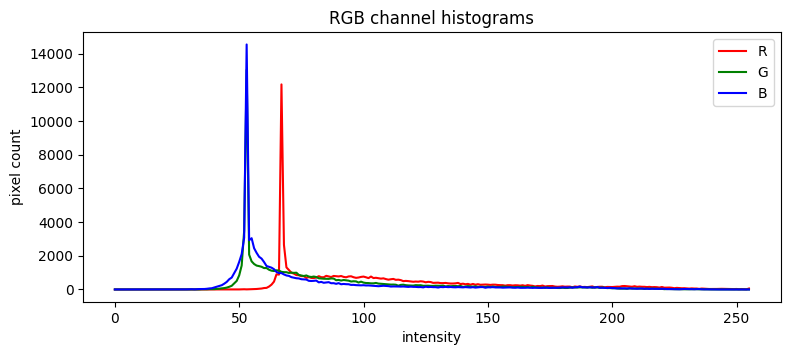

In [8]:
plt.figure(figsize=(9, 3.5))
for i, (name, col) in enumerate(zip(['R', 'G', 'B'], ['red', 'green', 'blue'])):
    h = cv2.calcHist([rgb], [i], None, [256], [0, 256]).flatten()
    plt.plot(h, color=col, label=name)
plt.title('RGB channel histograms'); plt.xlabel('intensity'); plt.ylabel('pixel count'); plt.legend()
plt.show()

**Joint 3D histogram (HSV)** as a single feature vector: 8 bins per channel gives 8x8x8 = 512 values. HSV separates color (hue) from brightness, so it is less sensitive to lighting.

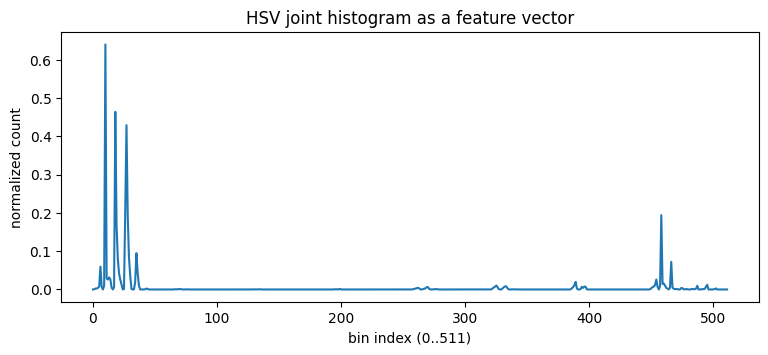

color feature vector length: 512
largest bin index: 10 (the most common color range)


In [9]:
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
color_hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256])
color_hist = cv2.normalize(color_hist, color_hist).flatten()

plt.figure(figsize=(9, 3.5))
plt.plot(color_hist)
plt.title('HSV joint histogram as a feature vector'); plt.xlabel('bin index (0..511)'); plt.ylabel('normalized count')
plt.show()
print('color feature vector length:', color_hist.shape[0])
print('largest bin index:', int(color_hist.argmax()), '(the most common color range)')

**Takeaway:** good for telling apart images by color (sunset vs forest). It cannot tell shapes or textures.

## 4. HED: Histogram of Edge Directions

**Idea:** count how many pixels have edges pointing in each of 8 directions (45 degrees apart) to find the dominant edge directions.

**Steps:** grayscale + Gaussian blur -> edge map -> gradient angle per pixel -> 8 bins over 360 degrees -> count.

**Step 1-2: blur and edge map.**

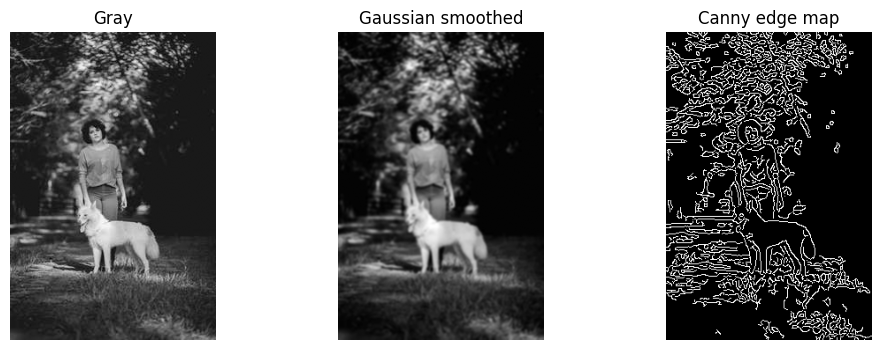

In [10]:
smoothed = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(smoothed, threshold1=30, threshold2=70)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gray, cmap='gray');      ax[0].set_title('Gray')
ax[1].imshow(smoothed, cmap='gray');  ax[1].set_title('Gaussian smoothed')
ax[2].imshow(edges, cmap='gray');     ax[2].set_title('Canny edge map')
for a in ax: a.axis('off')
plt.show()

**Step 3: gradient angle.** `arctan2` returns -180..180. The manual's code feeds that straight into a 0..360 histogram, which silently drops every negative angle.
The fix below wraps angles into 0..360 with `% 360`. The cell prints how many pixels each version counts.

In [11]:
gx = cv2.Sobel(smoothed, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(smoothed, cv2.CV_64F, 0, 1, ksize=3)
theta = np.degrees(np.arctan2(gy, gx))              # -180..180

h_manual, _ = np.histogram(theta, bins=8, range=(0, 360))
print('manual version counts', h_manual.sum(), 'of', theta.size, 'pixels (negative angles lost)')

theta360 = theta % 360                              # fix: wrap into 0..360
hist_hed, bin_edges = np.histogram(theta360, bins=8, range=(0, 360))
print('fixed version counts  ', hist_hed.sum(), 'of', theta360.size, 'pixels')

manual version counts 46794 of 81550 pixels (negative angles lost)
fixed version counts   81550 of 81550 pixels


**Step 4-5: 8 bins of 45 degrees, count pixels per bin.**

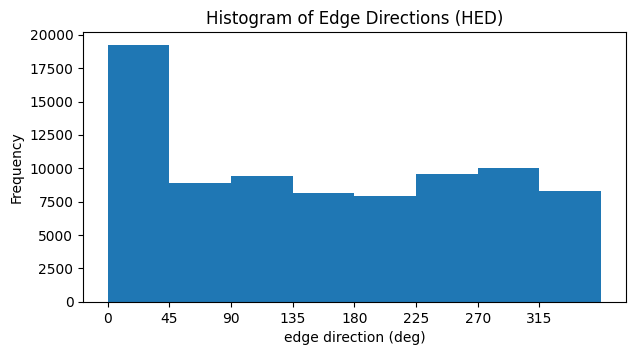

HED feature vector (8 values, normalized): [0.236 0.109 0.116 0.1   0.097 0.117 0.123 0.102]


In [12]:
plt.figure(figsize=(7, 3.5))
plt.bar(bin_edges[:-1], hist_hed, width=45, align='edge')
plt.title('Histogram of Edge Directions (HED)'); plt.xlabel('edge direction (deg)'); plt.ylabel('Frequency')
plt.xticks(range(0, 360, 45))
plt.show()
hed_vector = hist_hed / hist_hed.sum()
print('HED feature vector (8 values, normalized):', np.round(hed_vector, 3))

**Takeaway:** the gradient points across an edge. A tall bar near 0 or 180 degrees means the gradient points left-right, so the image has many vertical edges; bars near 90 or 270 mean many horizontal edges.

## 5. HIG: Histogram of Intensity Gradients

**Idea:** like HED but on the whole image with 9 bins over 0-180 degrees, optionally normalized. Unlike HOG there are no cells, so one global histogram.

**Steps:** grayscale -> Sobel dx, dy -> magnitude G = sqrt(dx^2 + dy^2) and angle = atan2(dy, dx) -> 9 bins -> normalize.

manual version counts 46751 of 81550 pixels (negative angles lost)


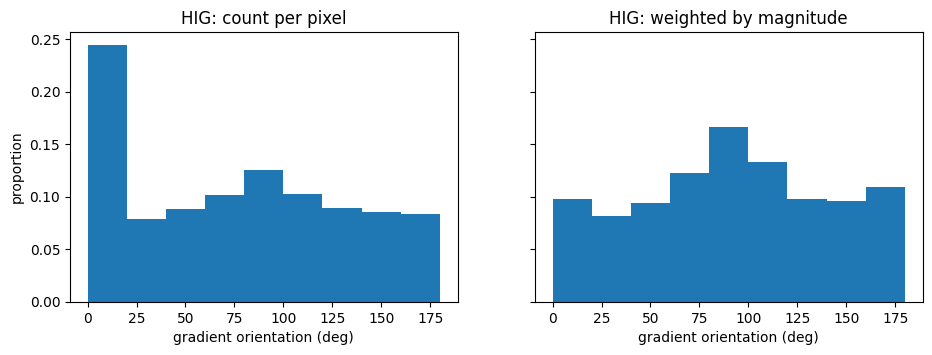

HIG feature vector (9 values, normalized): [0.244 0.079 0.088 0.102 0.126 0.102 0.089 0.085 0.084]


In [13]:
dx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
dy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(dx**2 + dy**2)
orientation = np.degrees(np.arctan2(dy, dx))        # -180..180

h_manual, _ = np.histogram(orientation, bins=9, range=(0, 180))
print('manual version counts', h_manual.sum(), 'of', orientation.size, 'pixels (negative angles lost)')

orientation180 = orientation % 180                  # fix: unsigned angle 0..180
hist_plain, bins = np.histogram(orientation180, bins=9, range=(0, 180))
hist_weighted, _ = np.histogram(orientation180, bins=9, range=(0, 180), weights=magnitude)

hist_plain_n    = hist_plain / hist_plain.sum()
hist_weighted_n = hist_weighted / hist_weighted.sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
ax[0].bar(bins[:-1], hist_plain_n, width=20, align='edge');    ax[0].set_title('HIG: count per pixel')
ax[1].bar(bins[:-1], hist_weighted_n, width=20, align='edge'); ax[1].set_title('HIG: weighted by magnitude')
for a in ax: a.set_xlabel('gradient orientation (deg)')
ax[0].set_ylabel('proportion')
plt.show()

hig_vector = hist_plain_n
print('HIG feature vector (9 values, normalized):', np.round(hig_vector, 3))

**Takeaway:** the weighted version lets strong edges count more than faint noise gradients, so it is usually the better feature.

## 6. Texture energy and contrast histograms

**Texture energy** = sum of squared pixel values in a window (how much signal). **Texture contrast** = standard deviation of pixel values in a window (how much variation, so how rough).

**Steps:** grayscale -> 3x3 window -> energy and contrast at every pixel -> histogram of each map.

The manual's code does `image ** 2` on a uint8 image (values wrap around) and calls a window *sum* "contrast". Below, we convert to float first and compute a real standard deviation.

**Step 1-3: energy and contrast maps.**

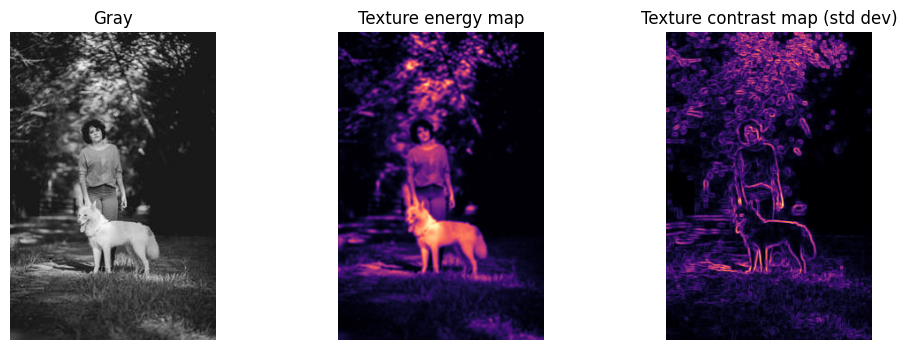

energy   range: 24135 .. 506160
contrast range: 0.0 .. 70.1


In [14]:
n = 3
f = gray.astype(np.float32)                         # float avoids uint8 overflow

energy = cv2.boxFilter(f * f, -1, (n, n), normalize=False)   # sum of squares in each 3x3 window
mean = cv2.blur(f, (n, n))
mean_sq = cv2.blur(f * f, (n, n))
contrast = np.sqrt(np.maximum(mean_sq - mean**2, 0))         # window standard deviation

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gray, cmap='gray');         ax[0].set_title('Gray')
ax[1].imshow(energy, cmap='magma');      ax[1].set_title('Texture energy map')
ax[2].imshow(contrast, cmap='magma');    ax[2].set_title('Texture contrast map (std dev)')
for a in ax: a.axis('off')
plt.show()
print('energy   range: %.0f .. %.0f' % (energy.min(), energy.max()))
print('contrast range: %.1f .. %.1f' % (contrast.min(), contrast.max()))

**Step 4: histograms = feature vectors.** Normalized so they sum to 1.

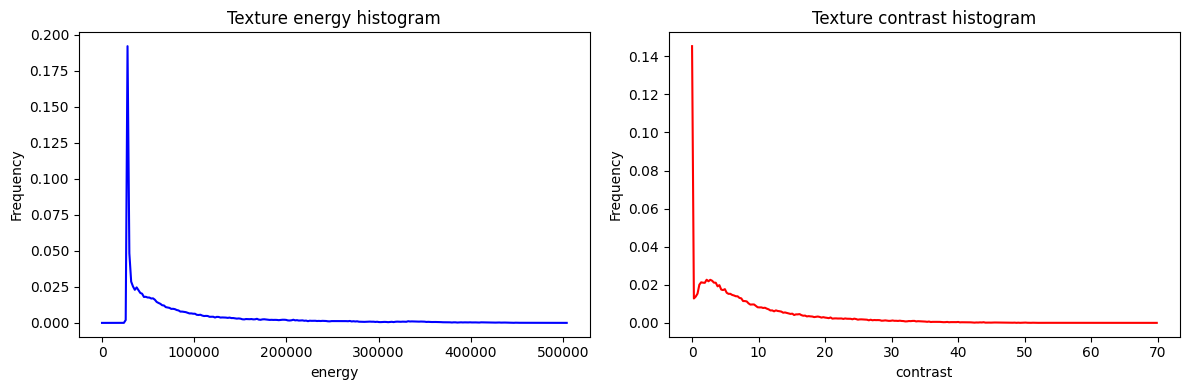

feature vectors: (256,) (256,)


In [15]:
energy_hist, energy_bins = np.histogram(energy, bins=256, range=(0, energy.max()))
contrast_hist, contrast_bins = np.histogram(contrast, bins=256, range=(0, contrast.max()))
energy_hist = energy_hist / energy_hist.sum()
contrast_hist = contrast_hist / contrast_hist.sum()

plt.figure(figsize=(12, 4))
plt.subplot(121); plt.plot(energy_bins[:-1], energy_hist, color='b')
plt.title('Texture energy histogram'); plt.xlabel('energy'); plt.ylabel('Frequency')
plt.subplot(122); plt.plot(contrast_bins[:-1], contrast_hist, color='r')
plt.title('Texture contrast histogram'); plt.xlabel('contrast'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()
print('feature vectors:', energy_hist.shape, contrast_hist.shape)

**Takeaway:** a smooth surface has a contrast histogram piled near 0. A rough or busy texture spreads to higher values.

## Compare the feature vectors

Same image, six different descriptions. This shows what each method keeps and what it throws away.

In [16]:
import pandas as pd
summary = pd.DataFrame({
    'Method':          ['HOG', 'LBP', 'Color (HSV)', 'HED', 'HIG', 'Energy hist', 'Contrast hist'],
    'Vector length':   [features.shape[0], lbp_vector.shape[0], color_hist.shape[0], hed_vector.shape[0],
                        hig_vector.shape[0], energy_hist.shape[0], contrast_hist.shape[0]],
    'Captures':        ['edge direction + location', 'micro-texture pattern', 'color makeup',
                        'dominant edge directions', 'gradient orientation spread',
                        'signal strength in windows', 'local variation (roughness)'],
    'Keeps location?': ['yes (per cell)', 'no', 'no', 'no', 'no', 'no', 'no'],
})
summary

,Method,Vector length,Captures,Keeps location?
0,HOG,42336,edge direction + location,yes (per cell)
1,LBP,10,micro-texture pattern,no
2,Color (HSV),512,color makeup,no
3,HED,8,dominant edge directions,no
4,HIG,9,gradient orientation spread,no
5,Energy hist,256,signal strength in windows,no
6,Contrast hist,256,local variation (roughness),no


## Quick revision

- **Histogram-based features** = count how often something occurs, then use the counts as the vector.
- **HOG** counts edge directions *per cell*, so it keeps rough shape.
- **LBP** counts neighbor-vs-center patterns, which describe texture.
- **Color histogram** counts pixels per color bin.
- **HED / HIG** count edge or gradient directions over the whole image (8 bins over 360 deg / 9 bins over 180 deg).
- **Energy / contrast** summarize local signal strength and local variation.
- **Always** convert to float before squaring, wrap angles into the histogram range, and normalize the histogram.